In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,LassoCV,RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler

In [106]:
house_df = pd.read_csv("HousePricePrediction.csv")

In [107]:
house_df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [108]:
house_df[house_df["BsmtFinSF2"]>0]

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
24,24,20,RL,8246,Inside,1Fam,8,1968,2001,Plywood,668.0,1060.0,154000.0
26,26,20,RL,7200,Corner,1Fam,7,1951,2000,Wd Sdng,486.0,900.0,134800.0
42,42,85,RL,9180,CulDSac,1Fam,7,1983,1983,HdBoard,93.0,840.0,144000.0
43,43,20,RL,9200,CulDSac,1Fam,6,1975,1980,VinylSd,491.0,938.0,130250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843,2843,80,RL,10385,CulDSac,1Fam,6,1978,1978,HdBoard,400.0,995.0,NaN
2858,2858,70,RL,8777,Inside,1Fam,6,1910,2000,Plywood,337.0,676.0,NaN
2862,2862,20,RL,8050,Inside,1Fam,5,2002,2002,VinylSd,297.0,914.0,NaN
2901,2901,20,RL,8098,Inside,1Fam,5,2000,2000,VinylSd,116.0,1381.0,NaN


In [109]:
house_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [110]:
mean=house_df["SalePrice"].mean()
house_df["SalePrice"]=house_df["SalePrice"].fillna(mean)

In [111]:
mean2=house_df["BsmtFinSF2"].mean()
house_df["BsmtFinSF2"]=house_df["BsmtFinSF2"].fillna(mean2)

In [112]:
mean3=house_df["TotalBsmtSF"].mean()
house_df["TotalBsmtSF"]=house_df["TotalBsmtSF"].fillna(mean3)

In [113]:
house_df=house_df.dropna()

In [114]:
house_df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.00000
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.00000
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.00000
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.00000
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,180921.19589
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,180921.19589
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,180921.19589
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,180921.19589


In [115]:
house_df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

<Axes: xlabel='LotConfig', ylabel='SalePrice'>

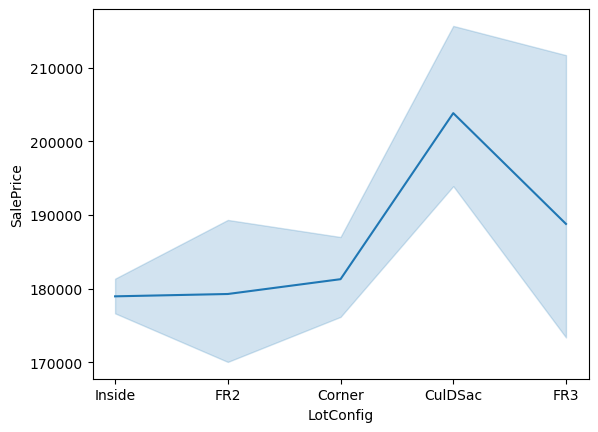

In [116]:
sns.lineplot(y=house_df["SalePrice"],x=house_df["LotConfig"])

In [117]:
house_df["BldgType"].value_counts()

BldgType
1Fam      2420
TwnhsE     227
Duplex     109
Twnhs       96
2fmCon      62
Name: count, dtype: int64

In [118]:
house_df["LotConfig"].value_counts()

LotConfig
Inside     2128
Corner      511
CulDSac     176
FR2          85
FR3          14
Name: count, dtype: int64

In [119]:
house_df["MSZoning"].value_counts()

MSZoning
RL         2264
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

In [160]:
X=house_df.drop(columns=["Exterior1st","Id","SalePrice"])
y=house_df["SalePrice"]

X=pd.get_dummies(X,columns=["MSZoning","BldgType","LotConfig"],drop_first=True,dtype=int)

X["totalbsmtfinsf"]=X["TotalBsmtSF"]+X["BsmtFinSF2"]

X["hasbsmt"]=(X["totalbsmtfinsf"]>0).astype(int)

X["remod_after_built"]=X["YearRemodAdd"]-X["YearBuilt"]
X["ageofbuild"]=2026-X["YearBuilt"]

In [162]:
X.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,BldgType_Twnhs,BldgType_TwnhsE,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,totalbsmtfinsf,hasbsmt,remod_after_built,ageofbuild
0,60,8450,5,2003,2003,0.0,856.0,0,0,1,...,0,0,0,0,0,1,856.0,1,0,23
1,20,9600,8,1976,1976,0.0,1262.0,0,0,1,...,0,0,0,1,0,0,1262.0,1,0,50
2,60,11250,5,2001,2002,0.0,920.0,0,0,1,...,0,0,0,0,0,1,920.0,1,1,25
3,70,9550,5,1915,1970,0.0,756.0,0,0,1,...,0,0,0,0,0,0,756.0,1,55,111
4,60,14260,5,2000,2000,0.0,1145.0,0,0,1,...,0,0,0,1,0,0,1145.0,1,0,26


In [163]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
scaled=StandardScaler()
X_train_scaled=scaled.fit_transform(X_train)
X_test_scaled=scaled.transform(X_test)

In [164]:
#Linear regression
LRG=LinearRegression()
LRG.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [165]:
#lassocv
alpha=np.arange(1,500,100)
lasso=LassoCV(
    alphas=alpha,
    cv=5,
    max_iter=5000,
    random_state=42
)
lasso.fit(X_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,"array([ 1, 1...01, 301, 401])"
,fit_intercept,True
,precompute,'auto'
,max_iter,5000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [166]:
models={"Linear Regression":LRG}
for name,model in models.items():
    y_pred=model.predict(X_test_scaled)
    print(f"\n{name}")
    mse=mean_squared_error(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    n=X_test.shape[0]
    p=X_test.shape[1]
    adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
    print(f"the Mean Squared Error of {name} is: {mse} ")
    print(f"The Mean Absolute error of {name} is: {mae}")
    print(f"the Root Mean Squared Error of {name} is: {np.sqrt(mse)}")
    print(f"the R2 Score of {name} is: {r2*100}%")
    print(f"the Adjusted R2 Score of {name} is: {adjusted_r2*100}%")
    


Linear Regression
the Mean Squared Error of Linear Regression is: 2553214917.3102355 
The Mean Absolute error of Linear Regression is: 33573.20369304546
the Root Mean Squared Error of Linear Regression is: 50529.34708968874
the R2 Score of Linear Regression is: 26.786733132834286%
the Adjusted R2 Score of Linear Regression is: 23.77438047103677%


In [167]:
mse

2553214917.3102355

In [168]:
modelss={"Lasso":lasso}
mse=[]
mae=[]
for name,models in modelss.items():
    y_pred=models.predict(X_test_scaled)
    print(f"\n{name}")
    mse=mean_squared_error(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    n=X_test.shape[0]
    p=X_test.shape[1]
    adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(f"the Mean Squared Error of {name} is: {mse} ")
print(f"The Mean Absolute error of {name} is: {mae}")
print(lasso.alpha_)
print(f"the Root Mean Squared Error of {name} is: {np.sqrt(mse)}")
print(f"the R2 Score of {name} is: {r2*100}%")
print(f"the Adjusted R2 Score of {name} is: {adjusted_r2*100}%")
    


Lasso
the Mean Squared Error of Lasso is: 2544817577.239439 
The Mean Absolute error of Lasso is: 33447.22557826302
301
the Root Mean Squared Error of Lasso is: 50446.18496218955
the R2 Score of Lasso is: 27.027526297330308%
the Adjusted R2 Score of Lasso is: 24.025081046594345%


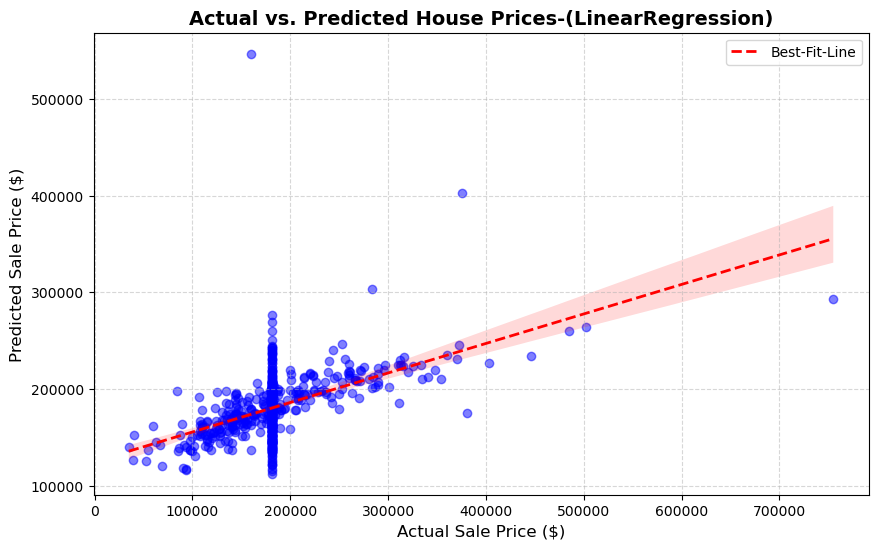

In [176]:
y_pred=LRG.predict(X_test_scaled)

plt.figure(figsize=(10,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha":0.5,"color":"blue"},
    line_kws={"color":"red","linewidth":2,"linestyle":"--","label":"Best-Fit-Line"}
)
plt.title('Actual vs. Predicted House Prices-(LinearRegression)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("linear regression.png", dpi=300, bbox_inches="tight")
plt.show()



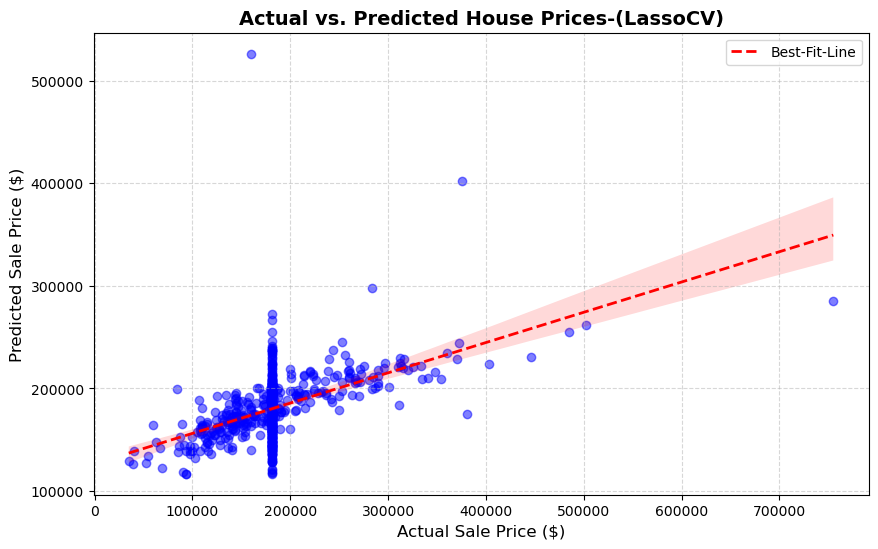

In [190]:
y_pred_=lasso.predict(X_test_scaled)

plt.figure(figsize=(10,6))

sns.regplot(
    x=y_test,
    y=y_pred_,
    scatter_kws={"alpha":0.5,"color":"blue"},
    line_kws={"color":"red","linewidth":2,"linestyle":"--","label":"Best-Fit-Line"}
)
plt.title('Actual vs. Predicted House Prices-(LassoCV)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("LassoCVV.png", dpi=300, bbox_inches="tight")
plt.show()

In [187]:
alpha=np.arange(1,500,100)
ridge=RidgeCV(
    alphas=alpha,
    cv=5,
)
ridge.fit(X_train_scaled,y_train)
    

,alphas,"array([ 1, 1...01, 301, 401])"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


Chosen Ridge Alpha: 1
Mean Squared Error: 2553214917.3102355
Mean Absolute Error: 33573.20369304546
Root Mean Squared Error: 50529.34708968874
R2 Score: 26.79%
Adjusted R2 Score: 23.77%


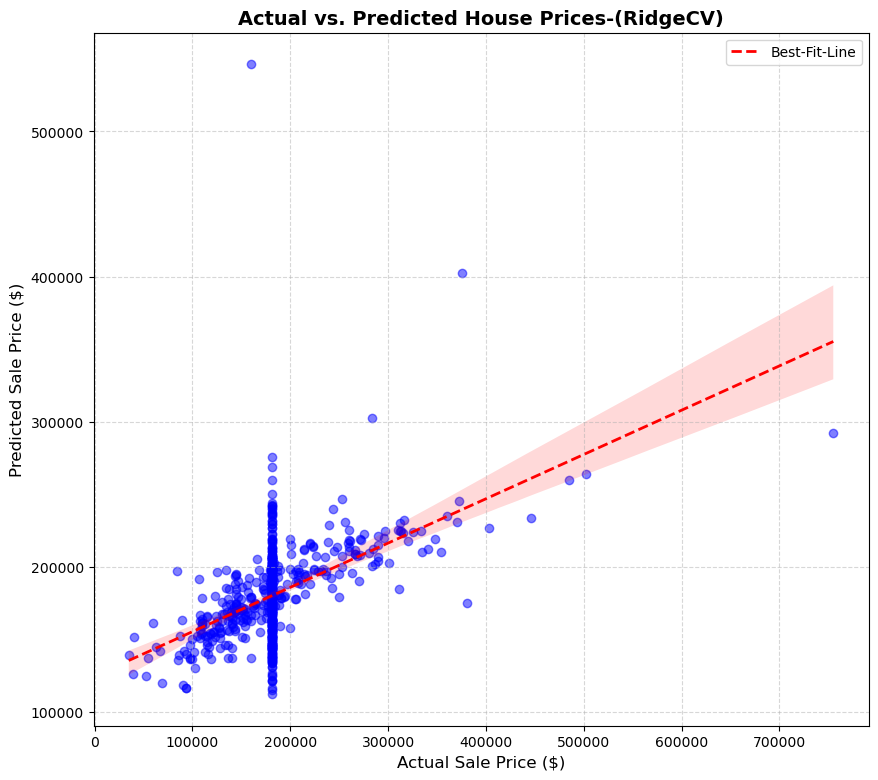

In [192]:
y_pred_ridge=ridge.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(f"Chosen Ridge Alpha: {ridge.alpha_}")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {np.sqrt(mse)}")
print(f"R2 Score: {r2 * 100:.2f}%")
print(f"Adjusted R2 Score: {adjusted_r2 * 100:.2f}%")

plt.figure(figsize=(10,9))

sns.regplot(
    x=y_test,
    y=y_pred_ridge,
    scatter_kws={"alpha":0.5,"color":"blue"},
    line_kws={"color":"red","linewidth":2,"linestyle":"--","label":"Best-Fit-Line"}
)
plt.title('Actual vs. Predicted House Prices-(RidgeCV)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("RidgeCV.png", dpi=300, bbox_inches="tight")
plt.show()
    
